In [65]:
# Loading some required liberaries
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from scipy import interpolate 
import scipy as scipy
#from cmcrameri import cm 
import math
import V2RhoT_gibbs_lib as lib


# Pressure

# Melt and atten functions

In [66]:
## melt fraction - mantle
def melt_frac_mantle_Hirschmann(T,P):
    """
    Hirschmann, 2000 and Winter, 2010
    P in GPa
    T in oC
    """
    T_s_m = 1080.0 + 134.2*P - 6.581*P**2 + 0.1054*P**3
    T_l_m = 1762.0 + 57.46*P  - 3.487*P**2 + 0.077*P**3
    melt  = (T - T_s_m)/(T_l_m - T_s_m)
    return melt
def melt_frac_mantle_Hirschmann(T, P):
    """
    Hirschmann, 2000 and Winter, 2010
    P in GPa, T in °C
    Supports both scalar values and NumPy arrays.
    """
    T_s_m = 1080.0 + 134.2*P - 6.581*P**2 + 0.1054*P**3
    T_l_m = 1762.0 + 57.46*P  - 3.487*P**2 + 0.077*P**3
    
    # Avoid potential division by zero if T_l_m equals T_s_m
    denominator = np.where(T_l_m == T_s_m, 1e-5, T_l_m - T_s_m)
    melt = (T - T_s_m) / denominator
    # Restrict bounds cleanly to [0.0, 1.0]
    return np.clip(melt, 0.0, 1.0)
def velocity_melt_correction_mantle_Hammond_Humphreys_new(T, P, Vp, Vs):
    """
    Hammond_Humphreys¸
    """
    ## get the melt fraction at the P and T
    melt_frac = melt_frac_mantle_Hirschmann(T,P)
    #########################
    # Vs:   -5.3 = dlnVs/melt_frac => dlnVs = -5.3 * melt_frac
    # Vp:   -2.4 = dlnVp/melt_frac => dlnVp = -2.4 * melt_frac
    if melt_frac > 0:
        dVs = -5.3 * melt_frac
        dVp = -2.4 * melt_frac
        Vs_corrected = Vs*np.exp(dVs)
        Vp_corrected = Vp*np.exp(dVp)
    else:
        Vp_corrected = Vp
        Vs_corrected = Vs
        melt_frac    = 0.
    return Vp_corrected,Vs_corrected, melt_frac*100.
def velocity_melt_correction_mantle_Hammond_Humphreys_orig(T,P,Vp,Vs):
    """
    Hammond_Humphreys¸
    """
    ## get the melt fraction at the P and T
    melt_frac = melt_frac_mantle_Hirschmann(T,P)
    #########################
    # Vs:   -5.3 = dlnVs/%melt => dlnVs = -5.3 * %melt
    # Vp:   -2.4 = dlnVp/%melt => dlnVp = -2.4 * %melt
    '''
    dVs = np.exp(-5.3 * melt_frac)
    dVp = np.exp(-2.3 * melt_frac)
    Vp_corrected = Vp - dVp
    Vs_corrected = Vs - dVs
    '''
    if melt_frac > 0:
        dVs = -5.3 * melt_frac*100
        dVp = -2.4 * melt_frac*100
        Vs_corrected = Vs*np.exp(dVs)
        Vp_corrected = Vp*np.exp(dVp)
    else:
        Vp_corrected = Vp
        Vs_corrected = Vs
        melt_frac    = 0.
    return Vp_corrected,Vs_corrected, melt_frac*100.
def atten_correction_JF2010_orig(T,P,Vp,Vs,oscill,grain_size,alfa=0.36,energy=293e3):
    '''
    Jackson and Faul, 2010 and Kumar et al., 2020    
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - mm
    Output:
    Vp,Vs: km/s    
    '''
    ## Parameters from Jackson and Faule 2010, Kumar et al., 2020
    A = 816.0          # (𝑠^(−𝛼) 〖𝜇𝑚〗^(−𝛼))Pre-exponential factor (for d in micrometers)
    #A = 68          # 𝑠^(−𝛼) 〖𝑚𝑚〗^(−𝛼)Pre-exponential factor (for d in mm)
    #alfa   = 0.34      #------------ frequency dependence
    energy = 293e3  #------------ Activation energy
    volexp = 1.20e-5  #------------ Activation volume
    R      = 8.314472  #------------ Gas constant
    pi     = 3.1415926 #------------ shephard;s pie :)

    #################################################
    ## calculating Qp and Qs
    parexp    = math.exp((-(energy+(volexp*P)))/(R*(T)))
    sqatt50   = A*(((oscill*(1.0/(grain_size*1e3)))*parexp))**alfa
    Qp        = (1/sqatt50)*(9/4)
    Qs        = 1/sqatt50
    cots50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*0.5
    cotp50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-cots50)
    Vp_correc = Vp*(1.0-cotp50)
    return Vp_correc,Vs_correc

def atten_correction_JF2010_new(T,P,Vp,Vs,oscill,grain_size,A=68,alfa=0.36,energy=293e3,volexp=1.20e-5):
    '''
    Jackson and Faul, 2010 and Kumar et al., 2020    
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - mm
    Output:
    Vp,Vs: km/s    
    '''
    ## Parameters from Jackson and Faule 2010, Kumar et al., 2020
    #A = 68          # 𝑠^(−𝛼) 〖𝑚𝑚〗^(−𝛼)Pre-exponential factor (for d in mm)
    #alfa   = 0.34      #------------ frequency dependence
    #energy = 293e3  #------------ Activation energy
    #volexp = 1.20e-5  #------------ Activation volume
    R      = 8.314472  #------------ Gas constant
    pi     = 3.1415926 #------------ shephard;s pie :)

    #################################################
    ## calculating Qp and Qs
    parexp    = math.exp((-(energy+(volexp*P)))/(R*(T)))
    sqatt50   = A*(((oscill*(1.0/(grain_size)))*parexp))**alfa
    Qp        = (1/sqatt50)*(9/4)
    Qs        = 1/sqatt50
    cots50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*0.5
    cotp50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-cots50)
    Vp_correc = Vp*(1.0-cotp50)
    return Vp_correc,Vs_correc
def atten_correction_Behn2009_orig(T,P,Vp,Vs,oscill,d,COH):
    '''
    Behn et al., 2009 https://doi.org/10.1016/j.epsl.2009.03.014
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - meter
    COH - olivine water concentration (in H/10**6Si), e.g., 50 H/10**6Si --> dry; 1000 H/10**6Si --> wet equivalent to 125 +/- 75 ppm weight water cf Behn et al., 2009
    Output:
    '''
    frequency   =   1/oscill # CHECK THIS FOR OMEGA
    R           =   8.314    # gas constant
    pi          =   3.1415926 #------------ shephard;s pie :)
    pq_ref      =   1.09    #reference grain exponent 
    pq          =   1.0     # grain exponent 
    TQ_ref      =   1265    # refrence temperature in oC
    d_ref       =   1.24e-5 # reference grain size in meters 

    EQ_ref      =   505e3   # referene activation energy in J/mol
    EQ          =   420e3   #activation energy
    VQ_ref      =   1.2e-5  #reference activation volime m**3/mol 
    VQ          =   1.2e-5  #activation volume
    
    Bo          =   1.28e8  # prefactor for Q for omega=0.122 s^-1
    COH_ref     =   50      # H/10^6 Si
    PQ_ref      =   300e6 # reference pressure in Pa;
    rQ          =   1.2
    alpha       =   0.27

    B = Bo*d_ref**(pq-pq_ref)*(COH/COH_ref)**rQ*math.exp(((EQ+PQ_ref*VQ)-(EQ_ref+PQ_ref*VQ_ref))/(R*TQ_ref))
    
    Qs_inv=(B*d**(-1*pq)*frequency**(-1)*math.exp(-(EQ+P*VQ)/(R*T)))**alpha # Inverse of Anelastic factor
    Qp        = (1/Qs_inv)*(9/4)
    Qs        = 1/Qs_inv
    vs_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*0.5
    vp_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-vs_correction)
    Vp_correc = Vp*(1.0-vp_correction)
    return Vp_correc,Vs_correc
def atten_correction_Behn2009_new(T,P,Vp,Vs,oscill,d,COH):
    '''
    Behn et al., 2009 https://doi.org/10.1016/j.epsl.2009.03.014
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - meter
    COH - olivine water concentration (in H/10**6Si), e.g., 50 H/10**6Si --> dry; 1000 H/10**6Si --> wet equivalent to 125 +/- 75 ppm weight water cf Behn et al., 2009
    Output:
    '''
    frequency   =   1/oscill # CHECK THIS FOR OMEGA
    R           =   8.314    # gas constant
    pi          =   3.1415926 #------------ shephard;s pie :)
    pq_ref      =   1.09    #reference grain exponent 
    pq          =   1.0     # grain exponent 
    TQ_ref      =   1265+273.15    # refrence temperature in oC
    d_ref       =   1.24e-5 # reference grain size in meters 

    EQ_ref      =   505e3   # referene activation energy in J/mol
    EQ          =   420e3   #activation energy
    VQ_ref      =   1.2e-5  #reference activation volime m**3/mol 
    VQ          =   1.2e-5  #activation volume
    
    Bo          =   1.28e8  # prefactor for Q for omega=0.122 s^-1
    COH_ref     =   50      # H/10^6 Si
    PQ_ref      =   300e6 # reference pressure in Pa;
    rQ          =   1.2
    alpha       =   0.27

    B = Bo*d_ref**(pq-pq_ref)*(COH/COH_ref)**rQ*math.exp(((EQ+PQ_ref*VQ)-(EQ_ref+PQ_ref*VQ_ref))/(R*TQ_ref))
    
    Qs_inv=(B*d**(-1*pq)*frequency**(-1)*math.exp(-(EQ+P*VQ)/(R*T)))**alpha # Inverse of Anelastic factor
    Qp        = (1/Qs_inv)*(9/4)
    Qs        = 1/Qs_inv
    vs_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*0.5
    vp_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-vs_correction)
    Vp_correc = Vp*(1.0-vp_correction)
    return Vp_correc,Vs_correc
import numpy as np

def melt_frac_mantle_Hirschmann(T_degC, P_GPa):
    """
    Hirschmann (2000) parameterization for dry peridotite partial melting.
    
    Parameters
    ----------
    T_degC : float or numpy.ndarray
        Temperature [°C].
    P_GPa : float or numpy.ndarray
        Pressure [GPa].

    Returns
    -------
    melt : float or numpy.ndarray
        Melt volume fraction clipped to [0.0, 1.0].
    """
    T_s_m = 1080.0 + 134.2 * P_GPa - 6.581 * P_GPa**2 + 0.1054 * P_GPa**3
    T_l_m = 1762.0 + 57.46 * P_GPa - 3.487 * P_GPa**2 + 0.077 * P_GPa**3
    
    denominator = np.where(T_l_m == T_s_m, 1e-5, T_l_m - T_s_m)
    melt = (T_degC - T_s_m) / denominator
    return np.clip(melt, 0.0, 1.0)


def atten_correction_Takei2016_full(
    T,
    P,
    Vp_anh,
    Vs_anh,
    oscill,
    grain_size,
    phi=None,
    rho=3300.0,
    Tm=None,
    alpha=0.20,
    A_B=0.60,
    include_peak=True,
    A_P=0.02,
    x_P=1e4,
    sigma_P=1.8,
    alpha_phi=25.0,
    beta_s=2.5,
    beta_p=1.5,
    E_star=500e3,
    V_star=15e-6,
    m=1.5,
    d_ref=1e-3,
    tau_ref=1e-12,
    return_Q=False,
    return_eta=False,
    return_phi=False
):
    """
    Anelastic Attenuation, Velocity Dispersion, Viscosity, and Auto Melt Model
    after Yamauchi & Takei (2016), Takei (2017), and Hirschmann (2000).

    Parameters
    ----------
    T : float or numpy.ndarray
        Temperature [Kelvin].
    P : float or numpy.ndarray
        Pressure [Pascal].
    Vp_anh, Vs_anh : float or numpy.ndarray
        Pure solid unrelaxed velocities from Perple_X [km/s].
    oscill : float or numpy.ndarray
        Oscillation period [seconds].
    grain_size : float or numpy.ndarray
        Grain size d [meters] (e.g., 1 mm = 1e-3 m).
    phi : float or numpy.ndarray, optional
        Melt volume fraction [0.0 - 1.0]. If None, automatically computed via
        Hirschmann (2000).
    rho : float or numpy.ndarray, default=3300.0
        Rock density [kg/m^3] from Perple_X.
    Tm : float or numpy.ndarray, optional
        Solidus temperature [Kelvin]. If None, automatically set to Hirschmann's
        solidus T_s(P) in Kelvin for homologous scaling (T/Tm).
    alpha : float, default=0.20
        Background frequency exponent. Ref: Takei (2017).
    A_B : float, default=0.60
        Background amplitude factor. Ref: Yamauchi & Takei (2016).
    include_peak : bool, default=True
        Includes EAGBS high-frequency relaxation peak if True.
    A_P, x_P, sigma_P : float
        Peak amplitude (0.02), position (1e4), and log-width (1.8).
    alpha_phi : float, default=25.0
        Melt parameter for viscosity reduction. Ref: Takei & Holtzman (2009).
    beta_s, beta_p : float
        Melt frame weakening parameters for S-wave (2.5) and P-wave (1.5).
    E_star, V_star : float
        Activation energy [500 kJ/mol] and activation volume [15 cm^3/mol].
    m : float, default=1.5
        Grain-size exponent.
    d_ref, tau_ref : float
        Reference grain size [1e-3 m] and relaxation factor [1e-12 s].
    return_Q : bool, default=False
        If True, includes Qp and Qs in output tuple.
    return_eta : bool, default=False
        If True, includes effective shear viscosity eta [Pa*s] in output tuple.
    return_phi : bool, default=False
        If True, includes calculated/used melt fraction phi in output tuple.

    Returns
    -------
    Tuple containing requested outputs:
    - Vp_correc, Vs_correc : Attenuated/dispersed velocities [km/s]
    - (Optional) Qp, Qs     : Quality factors
    - (Optional) eta        : Effective shear viscosity [Pa*s]
    - (Optional) phi        : Melt fraction [0.0 - 1.0]
    """
    R = 8.314472  # Gas constant [J/(mol K)]
    omega = 2.0 * np.pi / oscill

    # Unit conversions for Hirschmann (2000)
    T_degC = T - 273.15
    P_GPa = P / 1e9

    # Calculate Hirschmann solidus in °C and Kelvin
    T_s_m_degC = 1080.0 + 134.2 * P_GPa - 6.581 * P_GPa**2 + 0.1054 * P_GPa**3
    T_solidus_K = T_s_m_degC + 273.15

    # Auto-compute melt fraction if phi is not explicitly provided
    if phi is None:
        phi = melt_frac_mantle_Hirschmann(T_degC, P_GPa)

    # Auto-assign solidus Tm (in Kelvin) if Tm is not explicitly provided
    if Tm is None:
        Tm = T_solidus_K

    # 1. Anharmonic Elastic Frame Weakening (Melt Effect on Unrelaxed Modulus)
    Vs_anh_eff = Vs_anh * (1.0 - beta_s * phi)  # km/s
    Vp_anh_eff = Vp_anh * (1.0 - beta_p * phi)  # km/s

    # 2. Solid-State Maxwell Relaxation Time
    gamma = (E_star + P * V_star) / (R * Tm)
    tau_M_solid = tau_ref * ((grain_size / d_ref) ** m) * np.exp(gamma * (Tm / T))

    # 3. Viscoelastic Relaxation Shift from Melt
    tau_M = tau_M_solid * np.exp(-alpha_phi * phi)  # [seconds]

    # 4. Effective Shear Viscosity Calculation
    G_inf_eff = rho * ((Vs_anh_eff * 1000.0) ** 2)  # [Pa]
    eta = tau_M * G_inf_eff                          # [Pa*s]

    # Normalized dimensionless frequency x = omega * tau_M
    x = omega * tau_M

    # 5. Background Attenuation
    inv_Qs_bg = A_B * (x ** (-alpha))

    # 6. Peak Attenuation (EAGBS Peak)
    if include_peak:
        inv_Qs_peak = A_P * np.exp(-0.5 * ((np.log(x) - np.log(x_P)) / sigma_P) ** 2)
        inv_Qs = inv_Qs_bg + inv_Qs_peak
        
        # Local logarithmic slope alpha_eff = -d(ln Qs^-1) / d(ln x)
        d_peak_d_lnx = inv_Qs_peak * (-(np.log(x) - np.log(x_P)) / (sigma_P ** 2))
        alpha_eff = alpha * (inv_Qs_bg / inv_Qs) - (d_peak_d_lnx / inv_Qs)
    else:
        inv_Qs = inv_Qs_bg
        alpha_eff = alpha

    alpha_eff = np.clip(alpha_eff, 0.01, 0.49)
    Qs = 1.0 / inv_Qs

    # 7. Physical Velocity Dispersion via Kramers-Kronig
    cot_term = 1.0 / np.tan(np.pi * alpha_eff / 2.0)
    cots50 = 0.5 * cot_term * inv_Qs

    L = (4.0 / 3.0) * (Vs_anh_eff / Vp_anh_eff) ** 2
    cotp50 = 0.5 * L * cot_term * inv_Qs
    Qp = Qs / L

    # 8. Corrected Velocities
    Vs_correc = Vs_anh_eff * (1.0 - cots50)
    Vp_correc = Vp_anh_eff * (1.0 - cotp50)

    # Output assembly
    results = [Vp_correc, Vs_correc]
    if return_Q:
        results.extend([Qp, Qs])
    if return_eta:
        results.append(eta)
    if return_phi:
        results.append(phi)

    return tuple(results) if len(results) > 2 else (Vp_correc, Vs_correc)

In [67]:
atten_correction_Takei2016_full(T, P, Vp, Vs, oscill, d,return_phi=True)


(np.float64(3.251825691349473),
 np.float64(0.19678022636371273),
 np.float64(0.3771824821406375))

In [127]:
T=1800
P=2e9
Vp=7.5
Vs=4.3
oscill=1
d=10
COH=100
# --- Execution ---
vp_tak, vs_tak = atten_correction_Takei2016_full(T, P, Vp, Vs, oscill, d)
vp_jf, vs_jf = atten_correction_JF2010_new(T, P, Vp, Vs, oscill, d)
vp_behn, vs_behn = atten_correction_Behn2009_new(T, P, Vp, Vs, oscill, d, COH)

# --- Output Formatting ---
print("================ ABSOLUTE VELOCITIES ================")
print(f"Takei: Vp = {vp_tak:.4f} km/s, Vs = {vs_tak:.4f} km/s")
print(f"JF:    Vp = {vp_jf:.4f} km/s, Vs = {vs_jf:.4f} km/s")
print(f"Behn:  Vp = {vp_behn:.4f} km/s, Vs = {vs_behn:.4f} km/s")

print("\n================ PERCENTAGE CHANGE ================")
print(f"Takei: dVp = {((vp_tak - Vp)/Vp)*100:+.2f}%, dVs = {((vs_tak - Vs)/Vs)*100:+.2f}%")
print(f"JF:    dVp = {((vp_jf - Vp)/Vp)*100:+.2f}%, dVs = {((vs_jf - Vs)/Vs)*100:+.2f}%")
print(f"Behn:  dVp = {((vp_behn - Vp)/Vp)*100:+.2f}%, dVs = {((vs_behn - Vs)/Vs)*100:+.2f}%")

================ ABSOLUTE VELOCITIES ================
Takei: Vp = 3.2554 km/s, Vs = 0.2327 km/s
JF:    Vp = 7.4620 km/s, Vs = 4.2509 km/s
Behn:  Vp = 7.4722 km/s, Vs = 4.2641 km/s

================ PERCENTAGE CHANGE ================
Takei: dVp = -56.59%, dVs = -94.59%
JF:    dVp = -0.51%, dVs = -1.14%
Behn:  dVp = -0.37%, dVs = -0.83%


In [69]:
import math

# -----------------------------------------------------------------------------
# Input Parameters
# -----------------------------------------------------------------------------
T = 1573          # Temperature [K]
P = 2e9           # Pressure [Pa]
Vp = 8.9          # Uncorrected Vp [km/s]
Vs = 4.2          # Uncorrected Vs [km/s]
oscill = 100      # Time period [s]
d_jf = 10         # Grain size for JF2010 [mm]
d_behn = 10       # Grain size for Behn2009 [m]
COH = 100         # Water content [H/10^6 Si]

# -----------------------------------------------------------------------------
# Execute Corrections
# -----------------------------------------------------------------------------
vp_b_new, vs_b_new = atten_correction_Behn2009_new(T, P, Vp, Vs, oscill, d_behn, COH)
vp_b_orig, vs_b_orig = atten_correction_Behn2009_orig(T, P, Vp, Vs, oscill, d_behn, COH)
vp_j_new, vs_j_new = atten_correction_JF2010_new(T, P, Vp, Vs, oscill, d_jf)
vp_j_orig, vs_j_orig = atten_correction_JF2010_orig(T, P, Vp, Vs, oscill, d_jf)
vp_j_orig, vs_j_orig = atten_correction_Takei2016_full(T, P, Vp, Vs, oscill, d_jf)

# -----------------------------------------------------------------------------
# Formatted Execution Printout
# -----------------------------------------------------------------------------
print("=" * 70)
print("                    ATTENUATION CORRECTION RUN SUMMARY                    ")
print("=" * 70)
print("INPUT PARAMETERS USED:")
print(f"  • Temperature (T)        : {T} K ({T - 273.15:.2f} °C)")
print(f"  • Pressure (P)           : {P:.2e} Pa ({P / 1e9:.2f} GPa)")
print(f"  • Uncorrected Vp         : {Vp:.4f} km/s")
print(f"  • Uncorrected Vs         : {Vs:.4f} km/s")
print(f"  • Wave Period (oscill)   : {oscill} s (Frequency = {1/oscill:.3f} Hz)")
print(f"  • Grain Size (d)         : {d_jf} mm (JF2010) / {d_behn} m (Behn2009)")
print(f"  • Water Content (COH)    : {COH} H/10^6 Si")
print("-" * 70)

runs = [
    ("Behn2009 (New)", vp_b_new, vs_b_new),
    ("Behn2009 (Orig)", vp_b_orig, vs_b_orig),
    ("JF2010 (New)", vp_j_new, vs_j_new),
    ("JF2010 (Orig)", vp_j_orig, vs_j_orig),
]
print(f"{'Model Version':<18} | {'Vp [km/s]':<10} | {'Vs [km/s]':<10} | {'dVp (%)':<8} | {'dVs (%)':<8}")
print("-" * 70)
for name, vp_c, vs_c in runs:
    dvp = ((vp_c - Vp) / Vp) * 100.0
    dvs = ((vs_c - Vs) / Vs) * 100.0
    print(f"{name:<18} | {vp_c:<10.4f} | {vs_c:<10.4f} | {dvp:<8.2f} | {dvs:<8.2f}")

print("=" * 70)

                    ATTENUATION CORRECTION RUN SUMMARY                    
INPUT PARAMETERS USED:
  • Temperature (T)        : 1573 K (1299.85 °C)
  • Pressure (P)           : 2.00e+09 Pa (2.00 GPa)
  • Uncorrected Vp         : 8.9000 km/s
  • Uncorrected Vs         : 4.2000 km/s
  • Wave Period (oscill)   : 100 s (Frequency = 0.010 Hz)
  • Grain Size (d)         : 10 mm (JF2010) / 10 m (Behn2009)
  • Water Content (COH)    : 100 H/10^6 Si
----------------------------------------------------------------------
Model Version      | Vp [km/s]  | Vs [km/s]  | dVp (%)  | dVs (%) 
----------------------------------------------------------------------
Behn2009 (New)     | 8.8640     | 4.1617     | -0.40    | -0.91   
Behn2009 (Orig)    | 8.8755     | 4.1740     | -0.27    | -0.62   
JF2010 (New)       | 8.8212     | 4.1163     | -0.89    | -1.99   
JF2010 (Orig)      | 8.8797     | 4.1677     | -0.23    | -0.77   


In [70]:
import numpy as np

# -----------------------------------------------------------------------------
# Input Parameters
# -----------------------------------------------------------------------------
T_degC = 1329# Temperature [°C]
P_GPa = 2.0       # Pressure [GPa]
Vp = 8.2          # Uncorrected Vp [km/s]
Vs = 4.5          # Uncorrected Vs [km/s]

# -----------------------------------------------------------------------------
# Execute Corrections
# -----------------------------------------------------------------------------
# Hirschmann (2000) Solidus and Liquidus
T_solidus = 1080.0 + 134.2 * P_GPa - 6.581 * (P_GPa**2) + 0.1054 * (P_GPa**3)
T_liquidus = 1762.0 + 57.46 * P_GPa - 3.487 * (P_GPa**2) + 0.0770 * (P_GPa**3)

vp_new, vs_new, melt_pct_new = velocity_melt_correction_mantle_Hammond_Humphreys_new(
    T_degC, P_GPa, Vp, Vs
)
vp_orig, vs_orig, melt_pct_orig = velocity_melt_correction_mantle_Hammond_Humphreys_orig(
    T_degC, P_GPa, Vp, Vs
)

# -----------------------------------------------------------------------------
# Formatted Execution Printout
# -----------------------------------------------------------------------------
print("=" * 75)
print("              MANTLE MELT FRACTION & VELOCITY CORRECTION SUMMARY           ")
print("=" * 75)
print("INPUT PARAMETERS USED:")
print(f"  • Temperature (T)        : {T_degC:.2f} °C ({T_degC + 273.15:.2f} K)")
print(f"  • Pressure (P)           : {P_GPa:.2f} GPa ({P_GPa * 1e9:.2e} Pa)")
print(f"  • Uncorrected Vp         : {Vp:.4f} km/s")
print(f"  • Uncorrected Vs         : {Vs:.4f} km/s")
print("-" * 75)
print("HIRSCHMANN (2000) THERMAL BOUNDS:")
print(f"  • Calculated Solidus (Ts): {T_solidus:.2f} °C")
print(f"  • Calculated Liquidus(Tl): {T_liquidus:.2f} °C")
print(f"  • Evaluated Melt Fraction: {melt_pct_new:.2f}% ({(melt_pct_new / 100.0):.4f} absolute)")
print("-" * 75)

runs = [
    ("HH (New - Fractional)", vp_new, vs_new, melt_pct_new),
    ("HH (Orig - Percent Bug)", vp_orig, vs_orig, melt_pct_orig),
]

print(f"{'Model Version':<23} | {'Vp [km/s]':<10} | {'Vs [km/s]':<10} | {'dVp (%)':<8} | {'dVs (%)':<8}")
print("-" * 75)

for name, vp_c, vs_c, m_pct in runs:
    dvp = ((vp_c - Vp) / Vp) * 100.0
    dvs = ((vs_c - Vs) / Vs) * 100.0
    print(f"{name:<23} | {vp_c:<10.4f} | {vs_c:<10.4f} | {dvp:<8.2f} | {dvs:<8.2f}")

print("=" * 75)

              MANTLE MELT FRACTION & VELOCITY CORRECTION SUMMARY           
INPUT PARAMETERS USED:
  • Temperature (T)        : 1329.00 °C (1602.15 K)
  • Pressure (P)           : 2.00 GPa (2.00e+09 Pa)
  • Uncorrected Vp         : 8.2000 km/s
  • Uncorrected Vs         : 4.5000 km/s
---------------------------------------------------------------------------
HIRSCHMANN (2000) THERMAL BOUNDS:
  • Calculated Solidus (Ts): 1322.92 °C
  • Calculated Liquidus(Tl): 1863.59 °C
  • Evaluated Melt Fraction: 1.12% (0.0112 absolute)
---------------------------------------------------------------------------
Model Version           | Vp [km/s]  | Vs [km/s]  | dVp (%)  | dVs (%) 
---------------------------------------------------------------------------
HH (New - Fractional)   | 7.9816     | 4.2396     | -2.66    | -5.79   
HH (Orig - Percent Bug) | 0.5515     | 0.0116     | -93.27   | -99.74  


In [71]:
def mantle_melt_atten_correction_Takei2016(Table,grain_size,oscillation):
    Table_atten_corrected = np.copy(Table)
    melt = np.zeros_like(Table_atten_corrected[:,0])

    for i in range(len(Table_atten_corrected)):
        Table_atten_corrected[i,3],Table_atten_corrected[i,4],melt[i] = atten_correction_Takei2016_full(Table_atten_corrected[i,0],Table_atten_corrected[i,1]*1e5,
                                                             Table_atten_corrected[i,3],Table_atten_corrected[i,4],oscillation,grain_size*1e-3,return_phi=True)
    Table_atten_corrected[:,5]=melt[:]*1e2
    return Table_atten_corrected




In [128]:
TABLE_DMM = np.loadtxt('./../databases/DMM_HP',comments='#') 
grain_size=10 # in mm
oscillation_period=1 # in seconds
COH=100
TABLE_DMM_corr_JF=lib.mantle_melt_atten_correction_JF2010(TABLE_DMM,grain_size,oscillation_period)
TABLE_DMM_corr_B=lib.mantle_melt_atten_correction_Behn2009(TABLE_DMM,grain_size,oscillation_period,COH)
TABLE_DMM_corr_Tk=mantle_melt_atten_correction_Takei2016(TABLE_DMM,grain_size,oscillation_period)


In [129]:
# Please make sure that you are following the ordering of x y z and velocity. For more info see the -h option in parrallel_conversion.py or Guidelines in the Gitlab. 
tomo_in = np.loadtxt('./../data_tomo/ak135f_to_convert.txt',comments='#')
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
DMM_aharm= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM);
DMM_Tk=lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_Tk)
DMM_B=lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_B)
DMM_JF=lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_JF)

#PUM_new= lib_new.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);



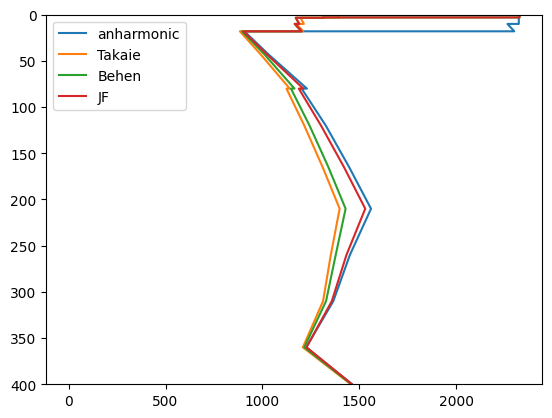

In [130]:
plt.plot(DMM_anhar[:,2],DMM_anhar[:,0],label='anharmonic')
plt.plot(DMM_Tk[:,2],DMM_anhar[:,0],label='Takaie')
plt.plot(DMM_B[:,2],DMM_anhar[:,0],label='Behen')
plt.plot(DMM_JF[:,2],DMM_anhar[:,0],label='JF')
plt.ylim(400,0)
plt.legend()

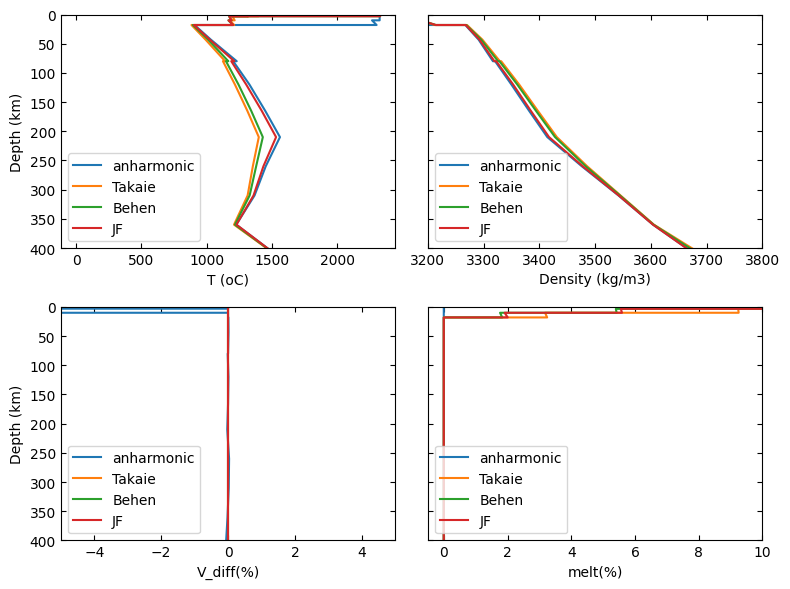

In [131]:
#Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
fig, axs = plt.subplots(2, 2, figsize=(8,6),sharey=True)
axes = axs.ravel()

# Define indices to plot for each panel
indices = [2, 3, 6, 7]
# Define your list of X-axis names here (make sure it matches the length of indices)
x_labels = ['T (oC)', 'Density (kg/m3)', 'V_diff(%)', 'melt(%)']
# Loop through each panel index and its corresponding axis
for i, idx in enumerate(indices):
    ax = axes[i]
    
    # Plot datasets for the current column index
    ax.plot(DMM_anhar[:, idx], DMM_anhar[:, 0], label='anharmonic')
    ax.plot(DMM_Tk[:, idx], DMM_anhar[:, 0], label='Takaie')
    ax.plot(DMM_B[:, idx], DMM_anhar[:, 0], label='Behen')
    ax.plot(DMM_JF[:, idx], DMM_anhar[:, 0], label='JF')
    # Customisations per panel
    #ax.set_title(x_labels[i])
    ax.set_xlabel(x_labels[i])  # Pulls the corresponding label from your list
    ax.tick_params(direction='in', top=True, right=True)
    ax.legend(loc='lower left')


# --- Specific Y-Axis Setup ---
# Set the inverted depth scale (automatically updates all due to sharey=True)
axes[0].set_ylim(400, 0) 

# Add Y-labels only to the leftmost panels (Column 0)
axs[0, 0].set_ylabel('Depth (km)')
axs[1, 0].set_ylabel('Depth (km)')

# Place a single legend on one of the panels (e.g., bottom-right)
axes[1].set_xlim(3200,3800)
axes[2].set_xlim(-5,5)
axes[3].set_xlim(-0.5,10)
plt.tight_layout()
plt.show()


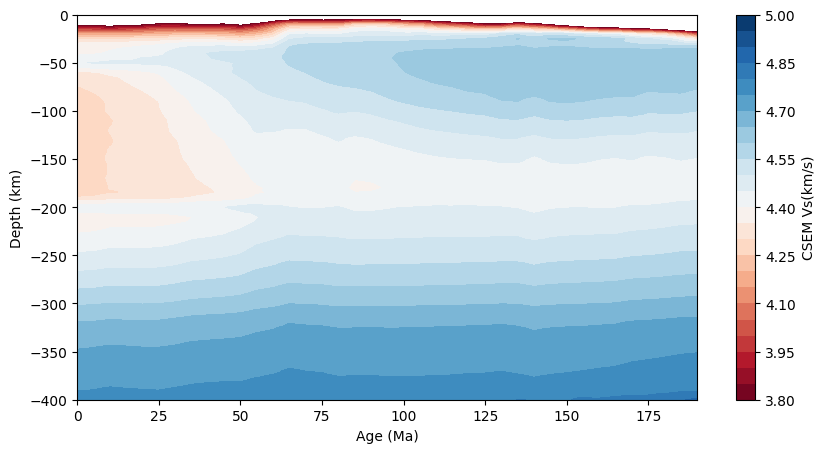

In [132]:
tomo_NA_stack = np.loadtxt('./../data_tomo/NA_age_vel_stack.dat',comments='#')
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True,figsize=(10,5))
m_v_in = ax.tricontourf(tri, tomo_NA_stack[:, 2],cmap='RdBu',levels=np.arange(3.8,5,0.05))
ax.set_ylim([-400,0])
ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Depth (km)')
fig.colorbar(m_v_in, ax=ax, label='CSEM Vs(km/s)', orientation='vertical')

In [133]:
OC_anhar= lib.vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM);
OC_Tk= lib.vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_Tk);
OC_B= lib.vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_B);
OC_JF= lib.vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_JF);


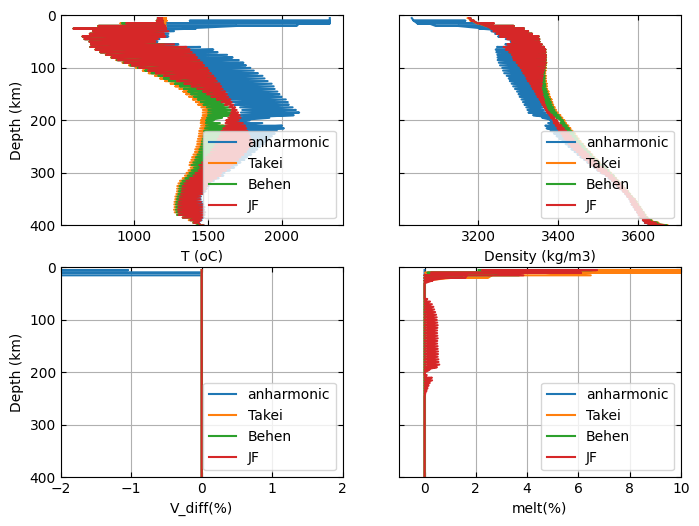

In [134]:
#Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
fig, axs = plt.subplots(2, 2, figsize=(8,6),sharey=True)
axes = axs.ravel()

# Define indices to plot for each panel
indices = [2, 3, 6, 7]
# Define your list of X-axis names here (make sure it matches the length of indices)
x_labels = ['T (oC)', 'Density (kg/m3)', 'V_diff(%)', 'melt(%)']
# Loop through each panel index and its corresponding axis
for i, idx in enumerate(indices):
    ax = axes[i]
    
    # Plot datasets for the current column index
    ax.plot(OC_anhar[:, idx], OC_anhar[:, 0], label='anharmonic')
    ax.plot(OC_Tk[:, idx], OC_anhar[:, 0], label='Takei')
    ax.plot(OC_B[:, idx], OC_anhar[:, 0], label='Behen')
    ax.plot(OC_JF[:, idx], OC_anhar[:, 0], label='JF')

    # Customisations per panel
    #ax.set_title(x_labels[i])
    ax.set_xlabel(x_labels[i])  # Pulls the corresponding label from your list
    ax.tick_params(direction='in', top=True, right=True)
    ax.legend(loc='lower right')
    ax.grid()

# --- Specific Y-Axis Setup ---
# Set the inverted depth scale (automatically updates all due to sharey=True)
axes[0].set_ylim(400, 0) 

# Add Y-labels only to the leftmost panels (Column 0)
axs[0, 0].set_ylabel('Depth (km)')
axs[1, 0].set_ylabel('Depth (km)')
# Place a single legend on one of the panels (e.g., bottom-right)
axes[2].set_xlim(-2,2)
axes[3].set_xlim(-1,10)
#plt.tight_layout()
plt.show()


# Temperature

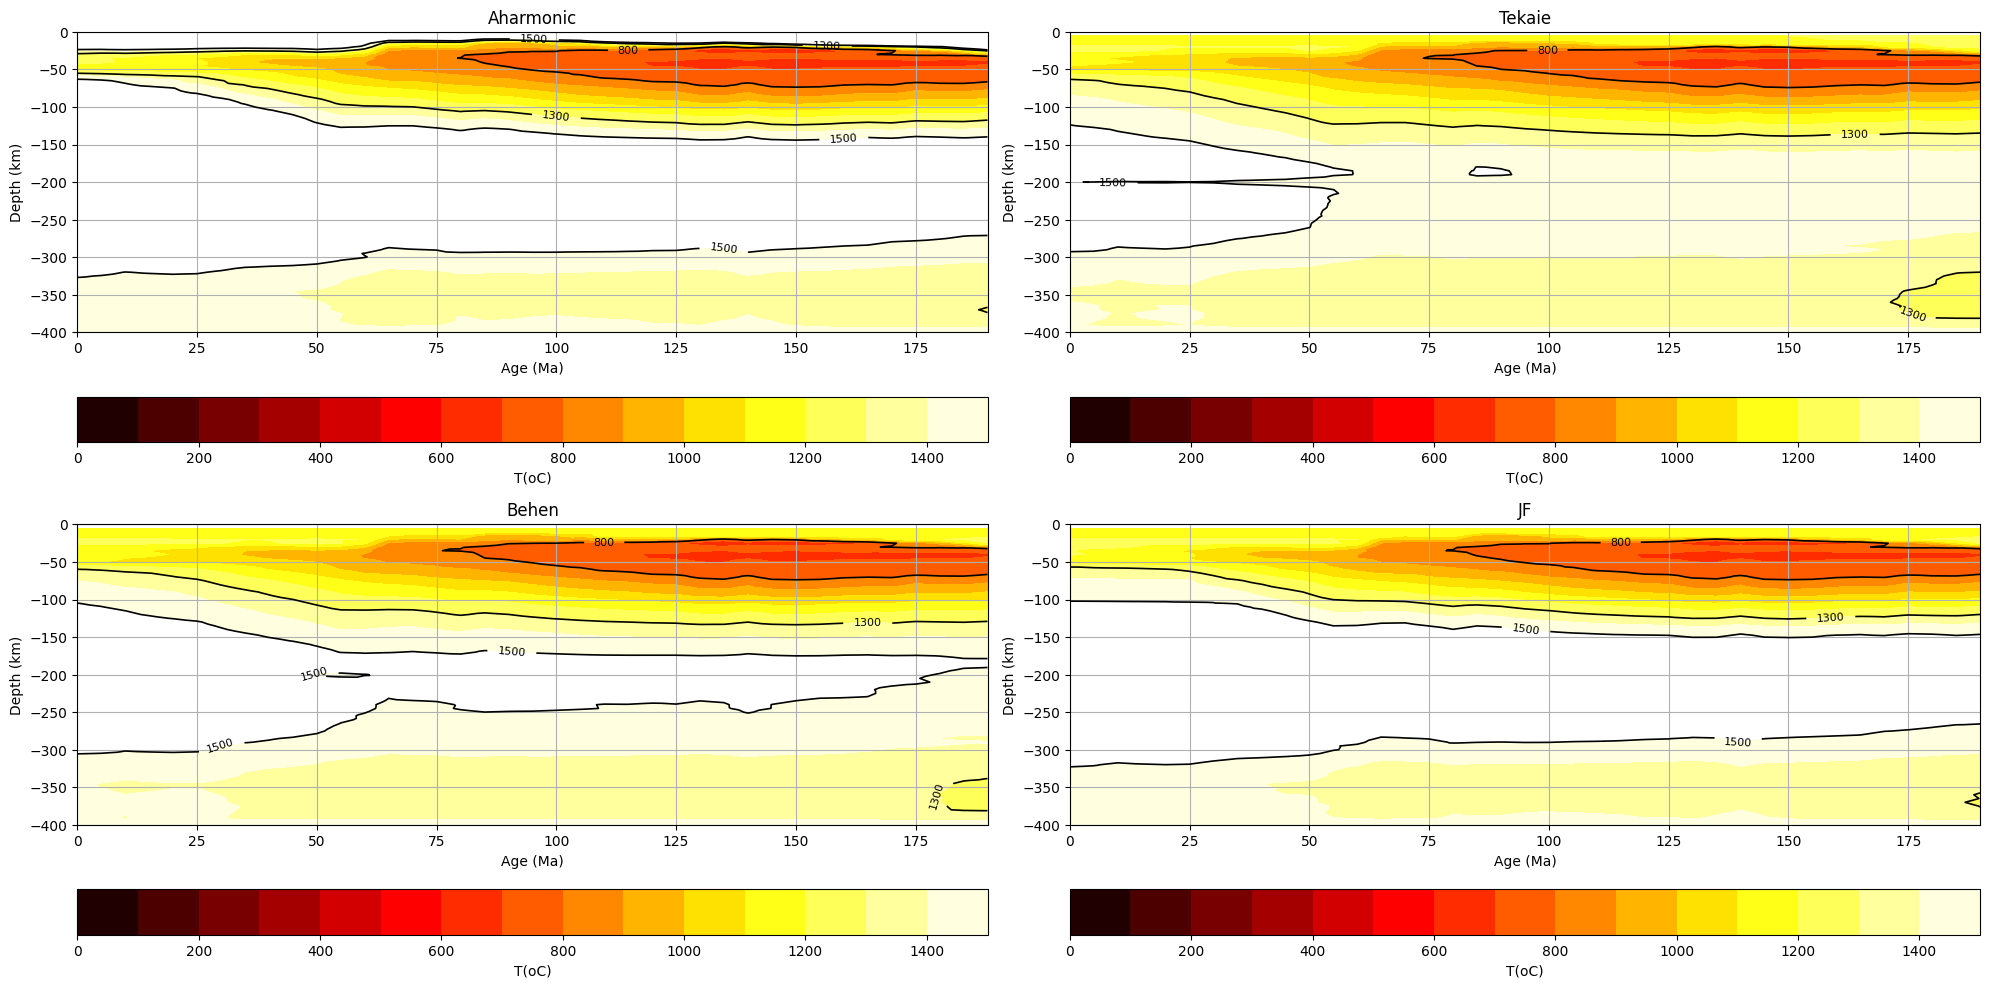

In [135]:
ind=2
name='T(oC)'
contour_list = [800, 1300, 1500]
levels=np.arange(0,1600,100)
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(2, 2,sharex=False, sharey=False,figsize=(20,10))
a=ax[0,0]
out_gibbs=OC_anhar.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')


a=ax[0,1]
out_gibbs=OC_Tk.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)#,levels=np.arange(-500,500,50))
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')



a=ax[1,0]
out_gibbs=OC_B.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)#,levels=np.arange(-500,500,50))
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')

a=ax[1,1]
out_gibbs=OC_JF.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)#,levels=np.arange(-500,500,50))
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')
for a in ax.flatten():
        #a.set_aspect('equal')
        a.set_ylim([-400,0])
        a.set_xlabel('Age (Ma)')
        a.set_ylabel('Depth (km)')
        a.set_title('')
        a.grid()

ax[0,0].set_title('Aharmonic')
ax[0,1].set_title('Tekaie')
ax[1,0].set_title('Behen')
ax[1,1].set_title('JF')
plt.tight_layout()


In [136]:
# Melt

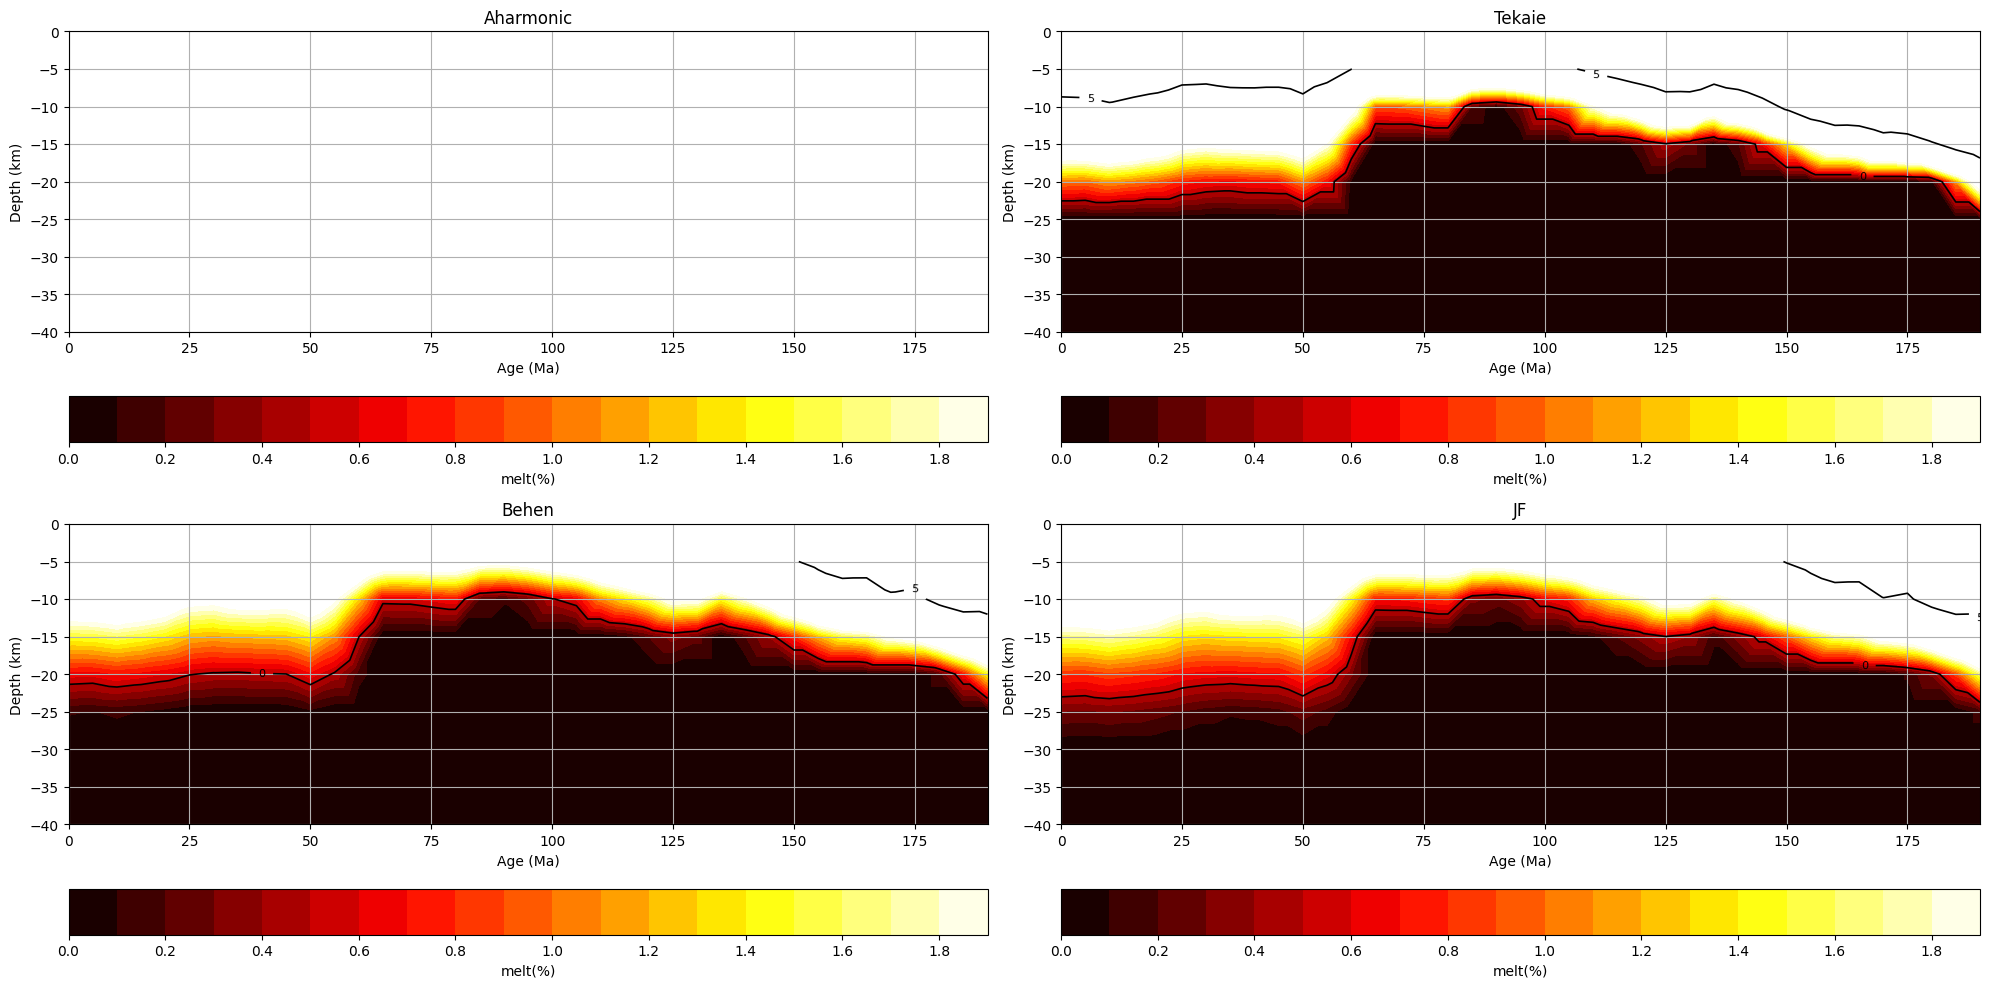

In [137]:
ind=-1
name='melt(%)'
contour_list = [0, 0.5, 5]
levels=np.arange(0,2,0.1)
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(2, 2,sharex=False, sharey=False,figsize=(20,10))
a=ax[0,0]
out_gibbs=OC_anhar.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')


a=ax[0,1]
out_gibbs=OC_Tk.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)#,levels=np.arange(-500,500,50))
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')



a=ax[1,0]
out_gibbs=OC_B.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)#,levels=np.arange(-500,500,50))
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')

a=ax[1,1]
out_gibbs=OC_JF.copy()
m_v_in_gibbs = a.tricontourf(tri, out_gibbs[:, ind],cmap='hot',levels=levels)#,levels=np.arange(-500,500,50))
m_v_in = a.tricontour(tri, out_gibbs[:, ind],levels=contour_list,colors='k',linewidths=1.2,linestyles='-')
# Label all contour lines in the list
a.clabel(m_v_in, inline=True, fontsize=8, fmt='%1.0f')
fig.colorbar(m_v_in_gibbs, ax=a, label=name, orientation='horizontal')
for a in ax.flatten():
        #a.set_aspect('equal')
        a.set_ylim([-40,0])
        a.set_xlabel('Age (Ma)')
        a.set_ylabel('Depth (km)')
        a.set_title('')
        a.grid()

ax[0,0].set_title('Aharmonic')
ax[0,1].set_title('Tekaie')
ax[1,0].set_title('Behen')
ax[1,1].set_title('JF')
plt.tight_layout()


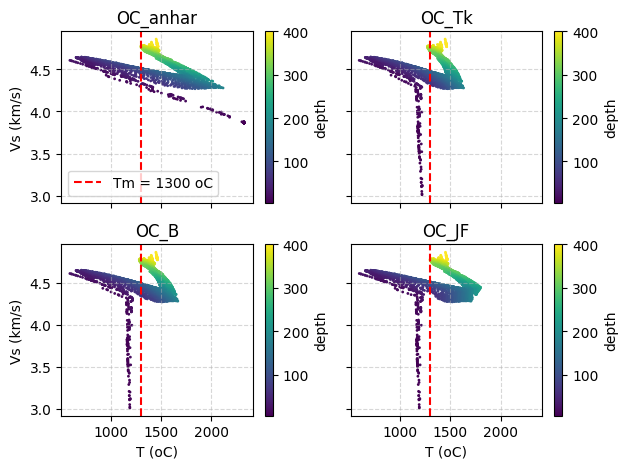

In [144]:
import matplotlib.pyplot as plt
ind = 0
name = 'depth'

# 1. Initialize a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)

# 2. Define your datasets and their corresponding titles
datasets = [
    (OC_anhar, "OC_anhar"),
    (OC_Tk, "OC_Tk"),
    (OC_B, "OC_B"),
    (OC_JF, "OC_JF")
]

# 3. Loop through the subplots and plot the data
for ax, (data, title) in zip(axes.flat, datasets):
    sc = ax.scatter(x=data[:, 2], y=data[:, -3], s=1, c=data[:, ind], cmap="viridis")
    ax.set_title(title, fontsize=12)
    ax.grid(True, which="both", ls="--", alpha=0.5) # Clean grid for log scale
    #ax.set_xscale('log')
    #ax.set_yscale('log')
    
    # --- ADD THE VERTICAL LINE HERE ---
    ax.axvline(x=1300, color='red', linestyle='--', linewidth=1.5, label='Tm = 1300 oC')
    #ax.set_xlim(800,1500)
    #ax.set_ylim(3.5,5.0)
    # Add a colorbar attached to the specific subplot
    cbar = fig.colorbar(sc, ax=ax, label=name)

# 4. Label the outer edges to keep it clean
for ax in axes[-1, :]: ax.set_xlabel("T (oC)")
for ax in axes[:, 0]:  ax.set_ylabel("Vs (km/s)")

# Add a legend to just one axis or a global one to show what the line means
axes[0, 0].legend(loc="lower left")

plt.tight_layout()
plt.show()


NameError: name 'DMM' is not defined

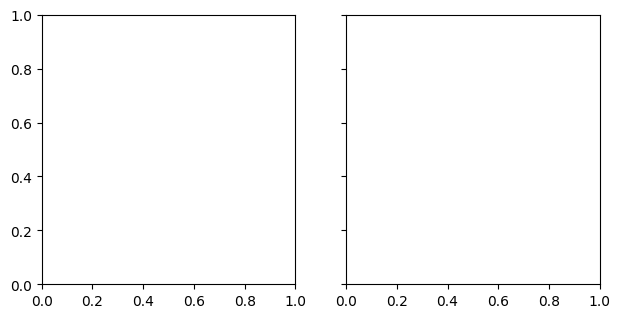

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5), sharey=True)

ax0 = axes[0]
# Plotting profiles
ax0.plot(DMM[:, 2], DMM[:, 0], label='DMM')
ax0.plot(Tc1[:, 2], Tc1[:, 0], label='Tc1')
ax0.plot(Pr1[:, 2], Pr1[:, 0], label='Pr1')
ax0.plot(Arc1[:, 2], Arc1[:, 0], label='Arc1')
# Formatting panel A
ax0.set_xlim(600, 1500)
ax0.set_xlabel('Temperature (°C)')
ax0.set_ylabel('Depth (km)')
ax0.legend(loc='lower left')
ax0.text(-0.15, 1.05, 'a', transform=ax0.transAxes, fontsize=10, fontweight='bold', va='top') # Nature panel label

ax1 = axes[1]
# Plotting profiles
ax1.plot(DMM[:, 3], DMM[:, 0], label='DMM')
ax1.plot(Tc1[:, 3], Tc1[:, 0], label='Tc1')
ax1.plot(Pr1[:, 3], Pr1[:, 0], label='Pr1')
ax1.plot(Arc1[:, 3], Arc1[:, 0], label='Arc1')
# Formatting panel B
ax1.set_xlim(3000, 3600)
ax1.set_xlabel('Density (kg/m³)')
ax1.text(-0.05, 1.05, 'b', transform=ax1.transAxes, fontsize=10, fontweight='bold', va='top')
# Only one legend is needed since the labels/colors match across panels
ax1.legend(loc='lower left')

for ax in axes:
    ax.set_ylim(400, 0) # Keeps the inverted depth scale
    ax.tick_params(direction='in', top=True, right=True) # Nature-style interior ticks

plt.tight_layout()
plt.show()

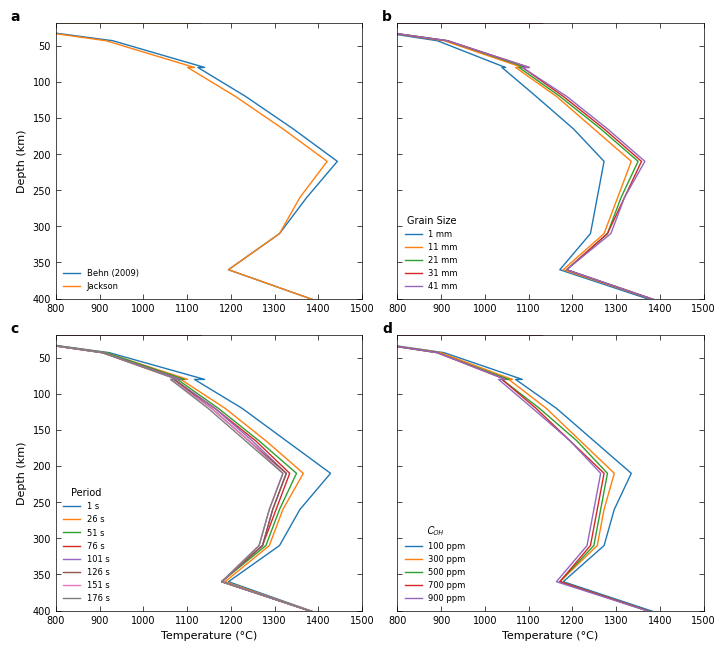

In [37]:
# Create a 2x2 grid sharing the depth (y) axis across columns
fig, axes = plt.subplots(2, 2, figsize=(7.2, 6.5), sharey=True)

# Unpack axes for easier readability
((ax_a, ax_b), (ax_c, ax_d)) = axes

# Global baseline constants
grain_size_base = 10
period_base = 100
coh_base = 100
# ----------------------------------------------------
# Panel A: Model Comparison (Behn vs Jackson)
# ----------------------------------------------------
# Behn 2009 Profile (table, grain_size, period, COH)
TABLE_DMM_corr = lib.mantle_melt_atten_correction_Behn2009(table_DMM, grain_size_base, period_base, 1)
PUM_behn = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_DMM_corr)
ax_a.plot(PUM_behn[:, 2], PUM_behn[:, 0], label='Behn (2009)')
# Jackson Profile (table, grain_size, period)
TABLE_PUM_corr = lib.mantle_melt_atten_correction(table_PUM, grain_size_base, period_base)
PUM_jack = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
ax_a.plot(PUM_jack[:, 2], PUM_jack[:, 0], label='Jackson')

ax_a.legend(loc='lower left')
ax_a.set_ylabel('Depth (km)')
ax_a.text(-0.15, 1.05, 'a', transform=ax_a.transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------------------------------
# Panel B: Sensitivity to Grain Size
# ----------------------------------------------------
for grain_size in range(1, 50, 10):
    # Fixed period=100, COH=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size, 100, 100)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_b.plot(DMM[:, 2], DMM[:, 0], label=f'{grain_size} mm')
ax_b.legend(title='Grain Size', loc='lower left')
ax_b.text(-0.05, 1.05, 'b', transform=ax_b.transAxes, fontsize=10, fontweight='bold', va='top')
# ----------------------------------------------------
# Panel C: Sensitivity to Oscillation Period
# ----------------------------------------------------
for oscillation_period in range(1, 200, 25):
    # Fixed grain_size=grain_size_base, COH=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size_base, oscillation_period, 100)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_c.plot(DMM[:, 2], DMM[:, 0], label=f'{oscillation_period} s')

ax_c.legend(title='Period', loc='lower left')
ax_c.set_xlabel('Temperature (°C)')
ax_c.set_ylabel('Depth (km)')
ax_c.text(-0.15, 1.05, 'c', transform=ax_c.transAxes, fontsize=10, fontweight='bold', va='top')


# ----------------------------------------------------
# Panel D: Sensitivity to Water Content (C_OH)
# ----------------------------------------------------
for COH in range(100, 1000, 200):
    # Fixed grain_size=grain_size_base, period=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size_base, 100, COH)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_d.plot(DMM[:, 2], DMM[:, 0], label=f'{COH} ppm')

ax_d.legend(title=r'$C_{OH}$', loc='lower left')
ax_d.set_xlabel('Temperature (°C)')
ax_d.text(-0.05, 1.05, 'd', transform=ax_d.transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------------------------------
# Global Layout Cleanups
# ----------------------------------------------------
for ax in axes.flat:
    ax.set_xlim(800, 1500)
    ax.set_ylim(400, 19)   # Inverted depth scale
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Effect of atten model

Text(0, 0.5, 'Depth (km)')

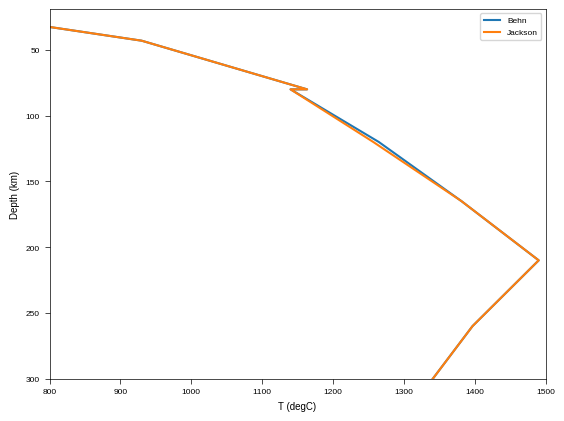

In [13]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes

grain_size=10
oscillation_period=1
COH=1
TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='Behn')

TABLE_PUM_corr=lib.mantle_melt_atten_correction(table_PUM,grain_size,oscillation_period)
PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='Jackson')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')

# Effect of grain size


Text(0, 0.5, 'Depth (km)')

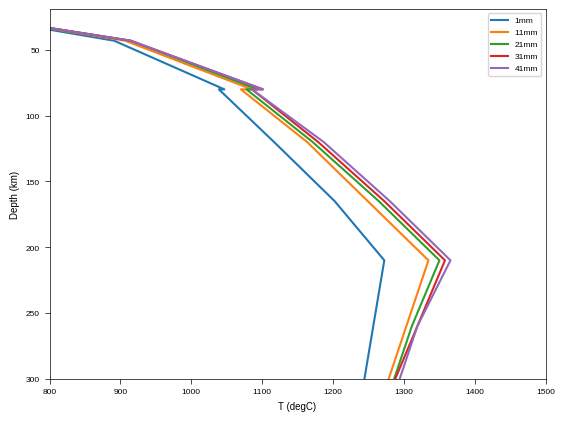

In [14]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
COH=100
oscillation_period=100
for grain_size in range(1,50,10):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(grain_size)+'mm')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


# Effect of Oscillation period

Text(0, 0.5, 'Depth (km)')

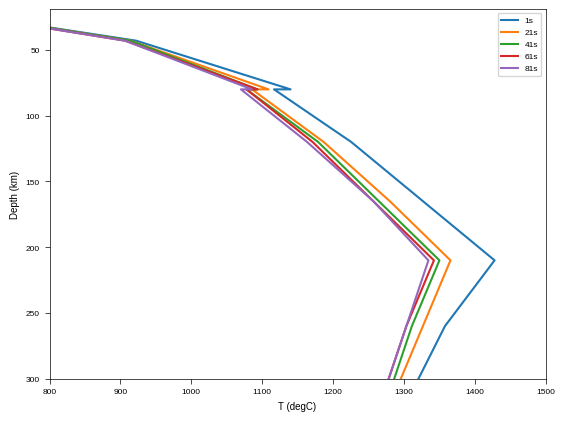

In [15]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
grain_size=10
COH=100
#oscillation_period=100
for oscillation_period in range(1,100,20):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(oscillation_period)+'s')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


# Effect of water COH

Text(0, 0.5, 'Depth (km)')

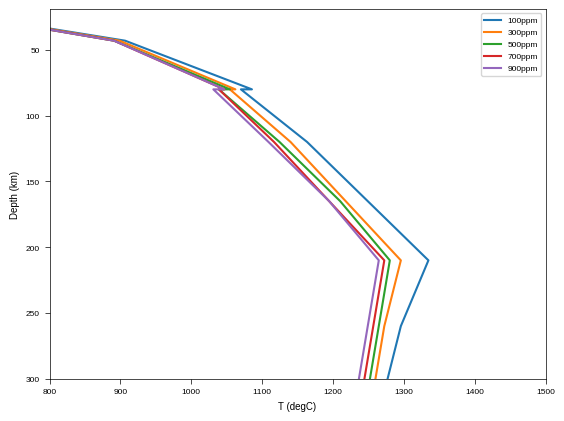

In [16]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
grain_size=10
oscillation_period=100
for COH in range(100,1000,200):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(COH)+'ppm')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


In [17]:
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
PUM= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_PUM_corr);
Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_Pr_1_corr);
Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_Arc_1_corr);


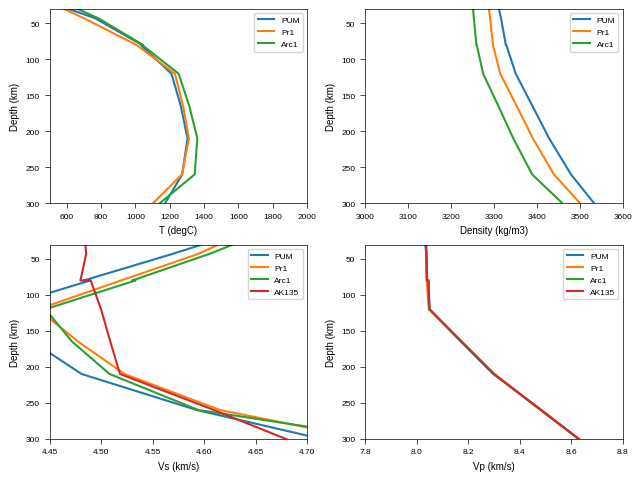

In [18]:
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes[0,0]
#PUM
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
ax.set_xlim(500,2000)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


#density
ax=axes[0,1]
#PUM
use=PUM.copy()
xplot=3 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
ax.set_xlim(3000,3600)
ax.set_xlabel('Density (kg/m3)');ax.set_ylabel('Depth (km)')


#Vs
ax=axes[1,0]
#PUM
use=PUM.copy()
xplot=5 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,3],tomo_in[:,0],label='AK135')
ax.legend()
ax.set_xlim(4.45,4.7)#ax.set_xlim(7.5,9)
ax.set_xlabel('Vs (km/s)');ax.set_ylabel('Depth (km)')



#Vp
ax=axes[1,1]
#PUM
use=PUM.copy()
xplot=4 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,2],tomo_in[:,0],label='AK135')
ax.legend()
ax.set_xlim(7.8,8.8)
ax.set_xlabel('Vp (km/s)');ax.set_ylabel('Depth (km)')

for i, ax in enumerate(axes.flat):
   ax.set_ylim(300,30)
    

plt.tight_layout()

In [22]:
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
PUM= lib.vel_vpvs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_PUM_corr);
Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Pr_1_corr);
Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Arc_1_corr);


/tmp/ipykernel_1505259/37867462.py:2: RuntimeWarning: divide by zero encountered in divide
  PUM= lib.vel_vpvs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_PUM_corr);
/home/ajay/projects/V2RhoT_gibbs/V2RhoT_gibbs_lib.py:1156: RuntimeWarning: invalid value encountered in scalar divide
  diff_VpVs.append(((VpVs_in-vp/vs)/VpVs_in)*100)
/tmp/ipykernel_1505259/37867462.py:3: RuntimeWarning: divide by zero encountered in divide
  Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Pr_1_corr);
/home/ajay/projects/V2RhoT_gibbs/V2RhoT_gibbs_lib.py:1112: RuntimeWarning: invalid value encountered in scalar divide
  diff_Vp.append(((Vp_in-vp)/Vp_in)*100)
/tmp/ipykernel_1505259/37867462.py:4: RuntimeWarning: divide by zero encountered in divide
  Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Arc_1_corr);


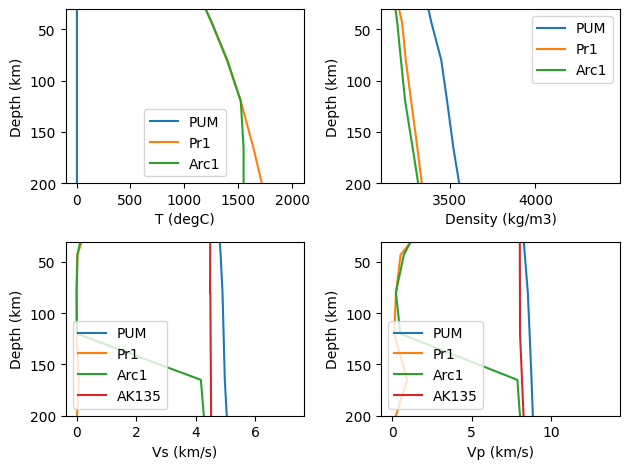

In [23]:
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes[0,0]
#PUM
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
#ax.set_xlim(500,2000)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


#density
ax=axes[0,1]
#PUM
use=PUM.copy()
xplot=3 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
#ax.set_xlim(3000,3600)
ax.set_xlabel('Density (kg/m3)');ax.set_ylabel('Depth (km)')


#Vs
ax=axes[1,0]
#PUM
use=PUM.copy()
xplot=5 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,3],tomo_in[:,0],label='AK135')
ax.legend()
#ax.set_xlim(4.45,4.7)#ax.set_xlim(7.5,9)
ax.set_xlabel('Vs (km/s)');ax.set_ylabel('Depth (km)')



#Vp
ax=axes[1,1]
#PUM
use=PUM.copy()
xplot=4 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,2],tomo_in[:,0],label='AK135')
ax.legend()
#ax.set_xlim(7.8,8.8)
ax.set_xlabel('Vp (km/s)');ax.set_ylabel('Depth (km)')

for i, ax in enumerate(axes.flat):
   ax.set_ylim(200,30)
    

plt.tight_layout()